In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent / "src"))

from config import load_config
from raymetrics.files import find_files_by_time, get_selected_file_paths
from raymetrics.simple_parser import read_lidar_file

In [6]:
paths = load_config('paths.yml')
usc_dir =  paths['paths']['usc_interim_dir']
uiuc_dir =  paths['paths']['uiuc_interim_dir']
lidar_dir = paths['paths']['lidar_dir']

In [7]:
# find all uiuc lidar data from a specific time range
uiuc_table = find_files_by_time(
    root_dir=uiuc_dir,
    source="UIUC",
    start_time="2018-10-15 23:00:00",
    end_time="2018-10-16 00:00:00",
)

uiuc_files = get_selected_file_paths(uiuc_table)
print(f'Number of UIUC files: {len(uiuc_files)}')

usc_table = find_files_by_time(
    root_dir=usc_dir,
    source="USC",
    start_time="2018-11-02 23:45:00",
    end_time="2018-11-03 00:00:00",
)

usc_files = get_selected_file_paths(usc_table)
print(f'Number of USC files: {len(usc_files)}')

Number of UIUC files: 14
Number of USC files: 51


In [8]:
usc_sample = usc_files[1]
print(usc_sample)
usc_meta, usc_profile = read_lidar_file(usc_sample, 'USC', 6)

C:\Users\ben\OneDrive - University of South Carolina\SAVANT_Data\01_interim\USC\11022018\S18B0223.450415.txt


In [9]:
usc_meta

{'source': 'USC',
 'file_name': 'S18B0223.450415.txt',
 'file_path': 'C:\\Users\\ben\\OneDrive - University of South Carolina\\SAVANT_Data\\01_interim\\USC\\11022018\\S18B0223.450415.txt',
 'measurement_name': 'S18B0223.450415',
 'header_lines': ['S18B0223.450415',
  'savant   02/11/2018 23:45:04 02/11/2018 23:45:04 0214 0040.2 0088.4 -1.70 3.00 6.0 1013.0',
  '02.8 03.2 00.2  00.3 -2.5 00.1  00.0',
  '0000005 0020 0000000 0000 02',
  '1 0 1 16340 1 0780 7.50 00355.o 0 0 00 000 12 000005 0.500 BT0',
  '1 1 1 16340 1 0750 7.50 00355.p 0 0 00 000 00 000005 2.7778 BC0'],
 'dataset_descriptors': [{'dataset_index': 0,
   'raw_descriptor': '1 0 1 16340 1 0780 7.50 00355.o 0 0 00 000 12 000005 0.500 BT0',
   'dataset_present': 1,
   'signal_mode': 0,
   'laser_source': 1,
   'n_bins': 16340,
   'pmt_high_voltage': 780.0,
   'bin_width_m': 7.5,
   'wavelength_nm': '00355.o',
   'dataset_label': '0.500',
   'recorder': 'BT0'},
  {'dataset_index': 1,
   'raw_descriptor': '1 1 1 16340 1 0750 7.50

# How to process signal
I need to look through each signal to see how different cleaning strategies work out...

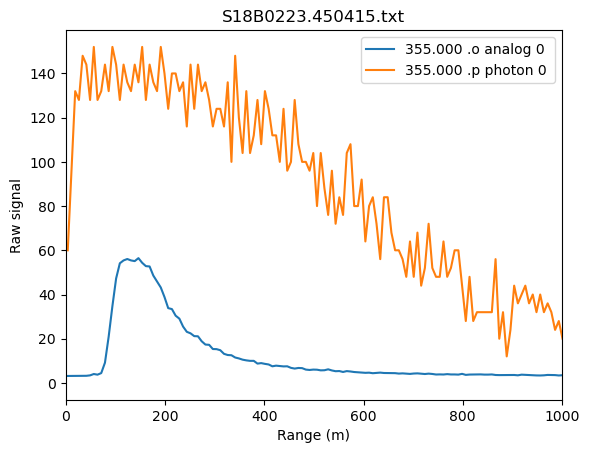

In [10]:
usc_profile.drop(columns=["range_bin"]).plot(x="range_m")
plt.xlim(0, 1000) # we know we are limited on space, so let's limit the x-axis to 1000 m

plt.xlabel("Range (m)")
plt.ylabel("Raw signal")
plt.title(usc_meta["file_name"])
plt.show()

In [11]:
from raymetrics.signal import estimate_background, process_backscatter_profile


In [12]:
bg = estimate_background(usc_profile['355.000 .o analog 0 '], usc_profile['range_m'], 0, 50)

In [13]:
bg

3.1982

In [14]:
usc_profile = usc_profile.rename(columns={'355.000 .o analog 0 ': 'analog'})

In [15]:
df = process_backscatter_profile(usc_profile, 'analog')

In [16]:
df

,range_bin,range_m,analog,355.000 .p photon 0,analog_background,analog_background_corrected,analog_range_corrected,analog_range_corrected_smoothed,valid_signal
0,0,3.75,3.1494,60.0,3.1494,0.0000,0.000000e+00,3.088125e+00,False
1,1,11.25,3.1738,96.0,3.1494,0.0244,3.088125e+00,9.950625e+00,False
2,2,18.75,3.2227,132.0,3.1494,0.0733,2.576953e+01,1.681312e+01,False
3,3,26.25,3.1738,128.0,3.1494,0.0244,1.681312e+01,2.576953e+01,False
4,4,33.75,3.1982,148.0,3.1494,0.0488,5.558625e+01,5.558625e+01,True
...,...,...,...,...,...,...,...,...,...
16335,16335,122516.25,3.1494,0.0,3.1494,0.0000,0.000000e+00,3.663393e+08,False
16336,16336,122523.75,3.2227,0.0,3.1494,0.0733,1.100385e+09,3.663393e+08,False
16337,16337,122531.25,3.1738,0.0,3.1494,0.0244,3.663393e+08,0.000000e+00,False
16338,16338,122538.75,3.1250,0.0,3.1494,-0.0244,-3.663842e+08,-2.242391e+04,False


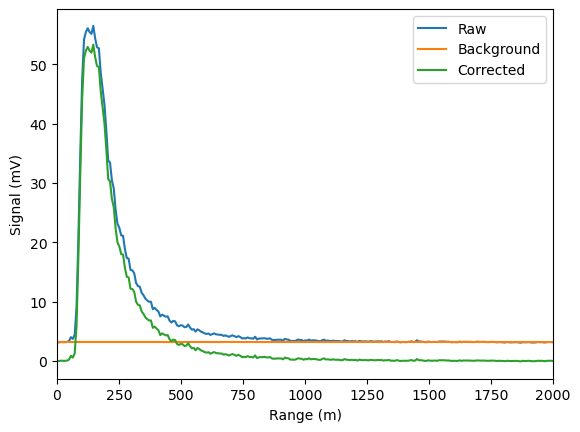

In [ ]:
plt.plot(df['range_m'],df['analog'], label='Raw')
plt.plot(df['range_m'],df['analog_background'], label='Background')
plt.plot(df['range_m'],df['analog_background_corrected'], label='Corrected')

# plt.plot(df['range_m'],df['analog_range_corrected'], label='Range Corrected') # put on secondary x axis


plt.xlim(0,2000)
plt.legend()
plt.xlabel("Range (m)")
plt.ylabel("Signal (mV)")

plt.show()

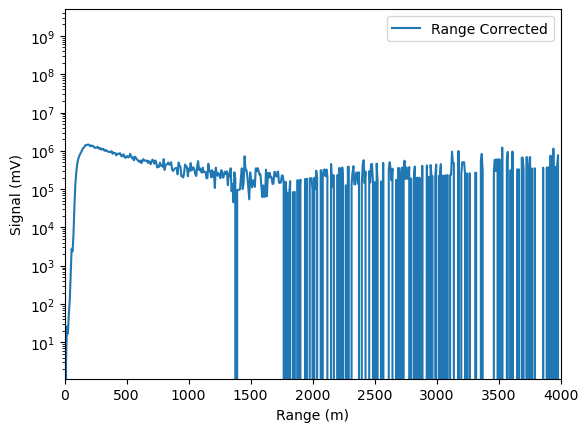

In [35]:

plt.plot(df['range_m'],df['analog_range_corrected'], label='Range Corrected') # put on secondary x axis

plt.yscale('log')
plt.xlim(0,4000)
plt.legend()
plt.xlabel("Range (m)")
plt.ylabel("Signal (mV)")

plt.show()

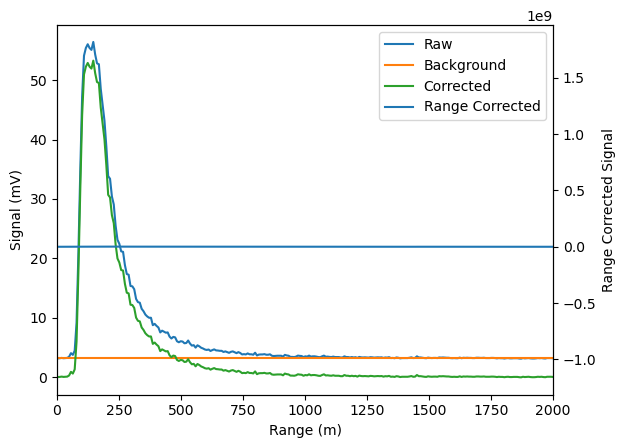

In [31]:
fig, ax1 = plt.subplots()

ax1.plot(df['range_m'], df['analog'], label='Raw')
ax1.plot(df['range_m'], df['analog_background'], label='Background')
ax1.plot(df['range_m'], df['analog_background_corrected'], label='Corrected')

ax1.set_xlim(0, 2000)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Signal (mV)")

ax2 = ax1.twinx()
ax2.plot(df['range_m'], df['analog_range_corrected'], label='Range Corrected')
ax2.set_ylabel("Range Corrected Signal")

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.show()

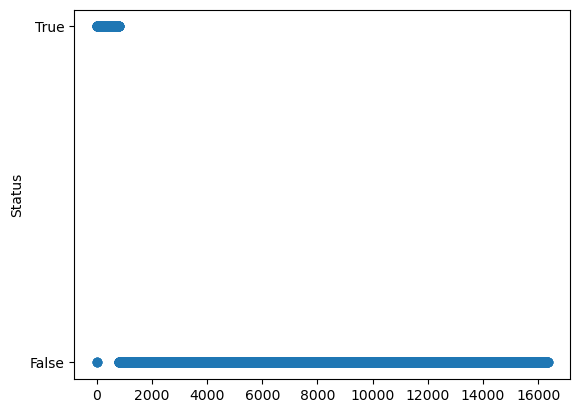

In [17]:
df['valid_signal'].astype(int).plot(marker='o', linestyle='')
plt.yticks([0, 1], ['False', 'True'])
plt.ylabel('Status')
plt.show()


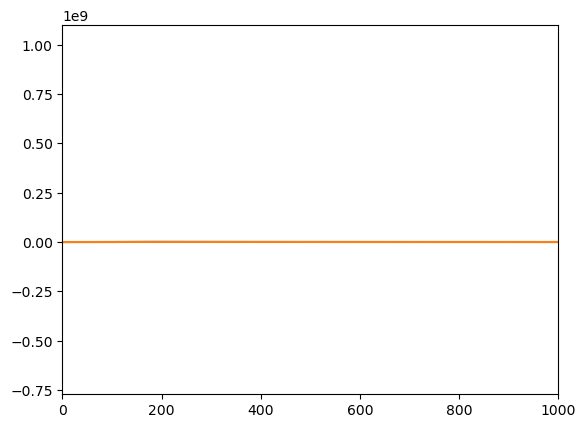

In [18]:
plt.plot(df['range_m'],df['analog_range_corrected_smoothed'])
plt.plot(df['range_m'],df['analog'])
plt.xlim(0,1000)
plt.show()

In [39]:
df.iloc[-25:]

,range_bin,range_m,analog,355.000 .p photon 0,analog_background,analog_background_corrected,analog_range_corrected,analog_range_corrected_smoothed,valid_signal
16315,16315,122366.25,3.1250,0.0,3.1494,-0.0244,-3.653534e+08,-3.653086e+08,False
16316,16316,122373.75,3.1494,0.0,3.1494,0.0000,0.000000e+00,-3.653086e+08,False
16317,16317,122381.25,3.1250,0.0,3.1494,-0.0244,-3.654430e+08,0.000000e+00,False
16318,16318,122388.75,3.1738,0.0,3.1494,0.0244,3.654877e+08,0.000000e+00,False
16319,16319,122396.25,3.1982,0.0,3.1494,0.0488,7.310651e+08,0.000000e+00,False
16320,16320,122403.75,3.1250,0.0,3.1494,-0.0244,-3.655773e+08,0.000000e+00,False
16321,16321,122411.25,3.1494,0.0,3.1494,0.0000,0.000000e+00,0.000000e+00,False
16322,16322,122418.75,3.1494,0.0,3.1494,0.0000,0.000000e+00,0.000000e+00,False
16323,16323,122426.25,3.1494,0.0,3.1494,0.0000,0.000000e+00,0.000000e+00,False
16324,16324,122433.75,3.1982,0.0,3.1494,0.0488,7.315131e+08,0.000000e+00,False


# Creating plot of all files looking at different processings


In [ ]:

ax1.plot(df['range_m'], df['analog'], label='Raw')
ax1.plot(df['range_m'], df['analog_background'], label='Background')
ax1.plot(df['range_m'], df['analog_background_corrected'], label='Corrected')

ax1.set_xlim(0, 2000)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Signal (mV)")

ax2 = ax1.twinx()
ax2.plot(df['range_m'], df['analog_range_corrected'], label='Range Corrected')
ax2.set_ylabel("Range Corrected Signal")

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.show()

In [41]:
df

,range_bin,range_m,analog,355.000 .p photon 0,analog_background,analog_background_corrected,analog_range_corrected,analog_range_corrected_smoothed,valid_signal
0,0,3.75,3.1494,60.0,3.1494,0.0000,0.000000e+00,3.088125e+00,False
1,1,11.25,3.1738,96.0,3.1494,0.0244,3.088125e+00,9.950625e+00,False
2,2,18.75,3.2227,132.0,3.1494,0.0733,2.576953e+01,1.681312e+01,False
3,3,26.25,3.1738,128.0,3.1494,0.0244,1.681312e+01,2.576953e+01,False
4,4,33.75,3.1982,148.0,3.1494,0.0488,5.558625e+01,5.558625e+01,True
...,...,...,...,...,...,...,...,...,...
16335,16335,122516.25,3.1494,0.0,3.1494,0.0000,0.000000e+00,3.663393e+08,False
16336,16336,122523.75,3.2227,0.0,3.1494,0.0733,1.100385e+09,3.663393e+08,False
16337,16337,122531.25,3.1738,0.0,3.1494,0.0244,3.663393e+08,0.000000e+00,False
16338,16338,122538.75,3.1250,0.0,3.1494,-0.0244,-3.663842e+08,-2.242391e+04,False


In [42]:
df.loc[df['analog_range_corrected_smoothed'] < 0, 'analog_range_corrected_smoothed'] = 0

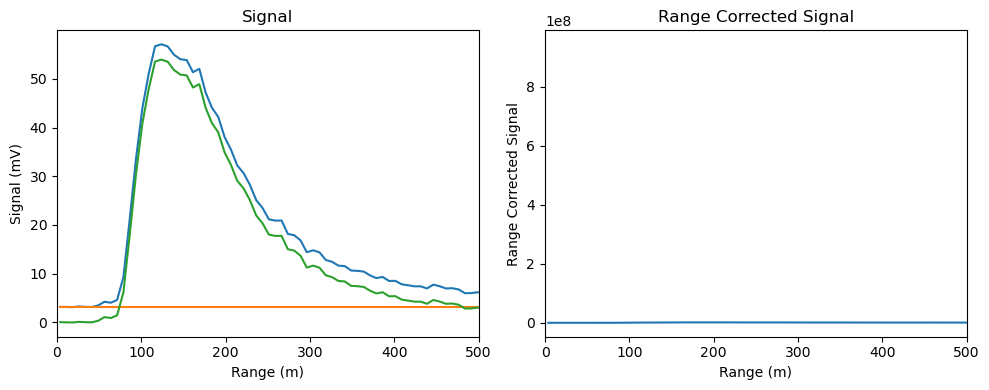

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# 3. Construct the first subplot to show the raw, background, and corrected signals
ax1.plot(df['range_m'], df['analog'], label='Raw')
ax1.plot(df['range_m'], df['analog_background'], label='Background')
ax1.plot(df['range_m'], df['analog_background_corrected'], label='Corrected')

ax1.set_title('Signal')
ax1.set_xlim(0, 500)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Signal (mV)")

# 4. Construct the second subplot to show the corrected signal
ax2.plot(df['range_m'], df['analog_range_corrected_smoothed'], label='Range Corrected')
ax2.set_ylabel("Range Corrected Signal")
ax2.set_title('Range Corrected Signal')
ax2.set_xlabel("Range (m)")
# ax2.set_ylabel("Signal (mV)")

ax2.set_xlim(0, 500)


# 5. Fix potential layout overlapping and display
plt.tight_layout()
plt.show()

In [55]:
usc_meta

{'source': 'USC',
 'file_name': 'S18B0223.450415.txt',
 'file_path': 'C:\\Users\\ben\\OneDrive - University of South Carolina\\SAVANT_Data\\01_interim\\USC\\11022018\\S18B0223.450415.txt',
 'measurement_name': 'S18B0223.450415',
 'header_lines': ['S18B0223.450415',
  'savant   02/11/2018 23:45:04 02/11/2018 23:45:04 0214 0040.2 0088.4 -1.70 3.00 6.0 1013.0',
  '02.8 03.2 00.2  00.3 -2.5 00.1  00.0',
  '0000005 0020 0000000 0000 02',
  '1 0 1 16340 1 0780 7.50 00355.o 0 0 00 000 12 000005 0.500 BT0',
  '1 1 1 16340 1 0750 7.50 00355.p 0 0 00 000 00 000005 2.7778 BC0'],
 'dataset_descriptors': [{'dataset_index': 0,
   'raw_descriptor': '1 0 1 16340 1 0780 7.50 00355.o 0 0 00 000 12 000005 0.500 BT0',
   'dataset_present': 1,
   'signal_mode': 0,
   'laser_source': 1,
   'n_bins': 16340,
   'pmt_high_voltage': 780.0,
   'bin_width_m': 7.5,
   'wavelength_nm': '00355.o',
   'dataset_label': '0.500',
   'recorder': 'BT0'},
  {'dataset_index': 1,
   'raw_descriptor': '1 1 1 16340 1 0750 7.50

In [60]:
len(usc_files)

51

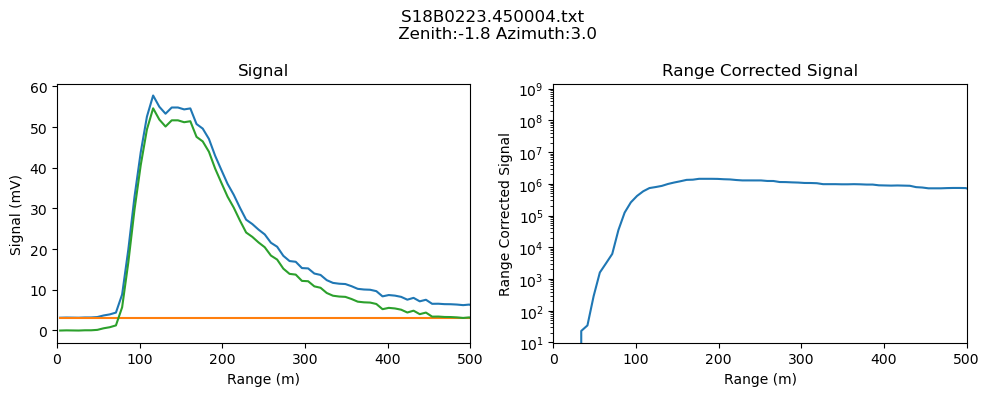

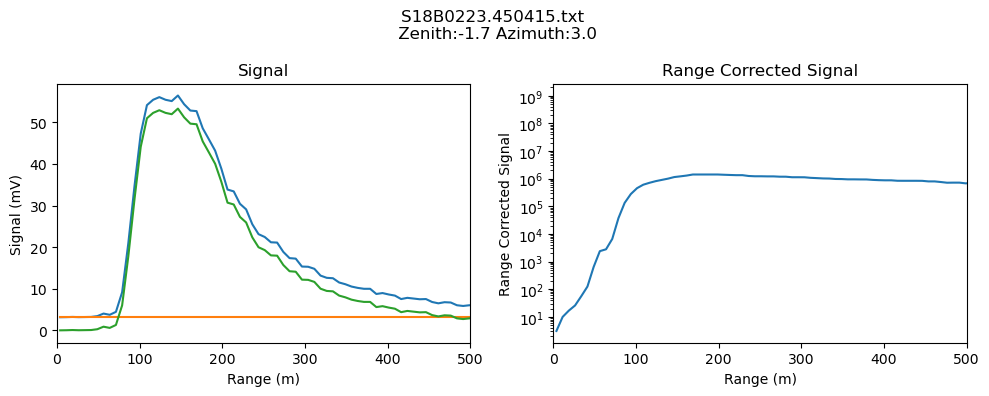

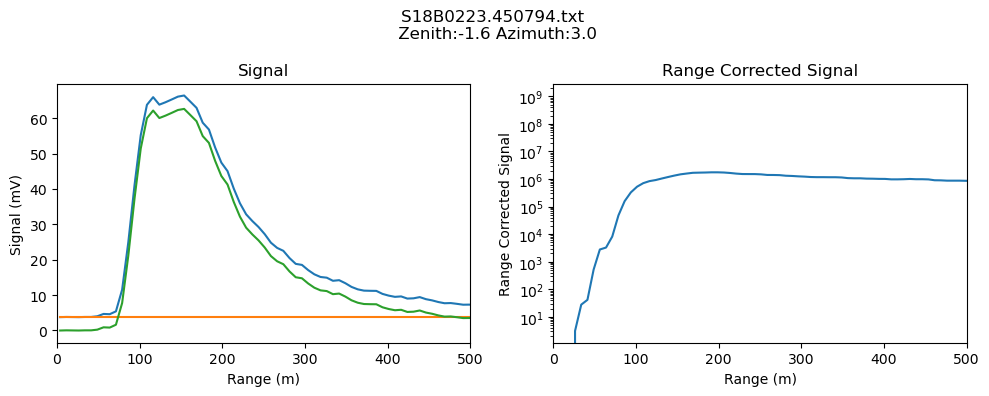

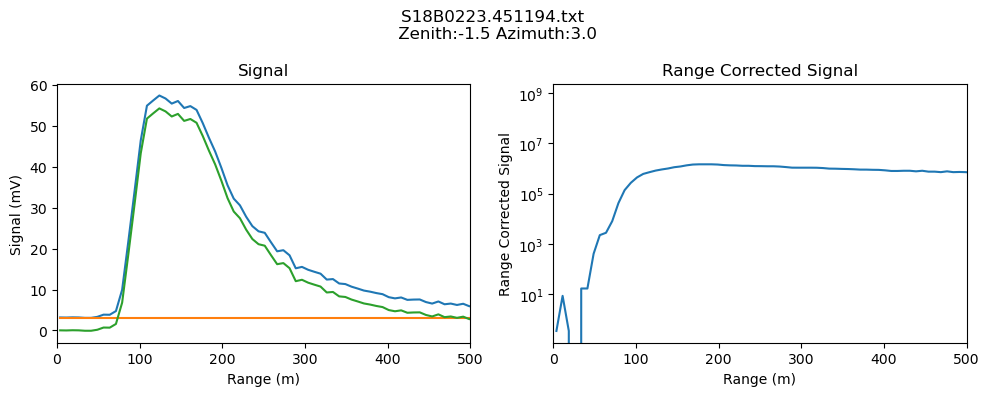

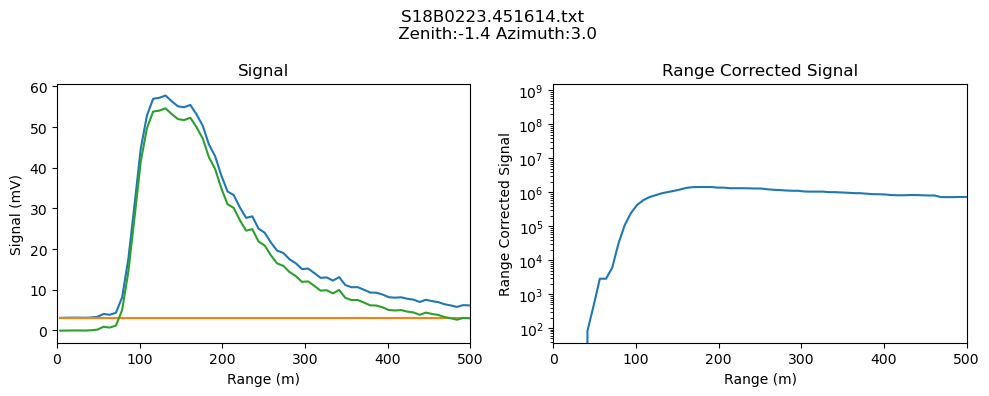

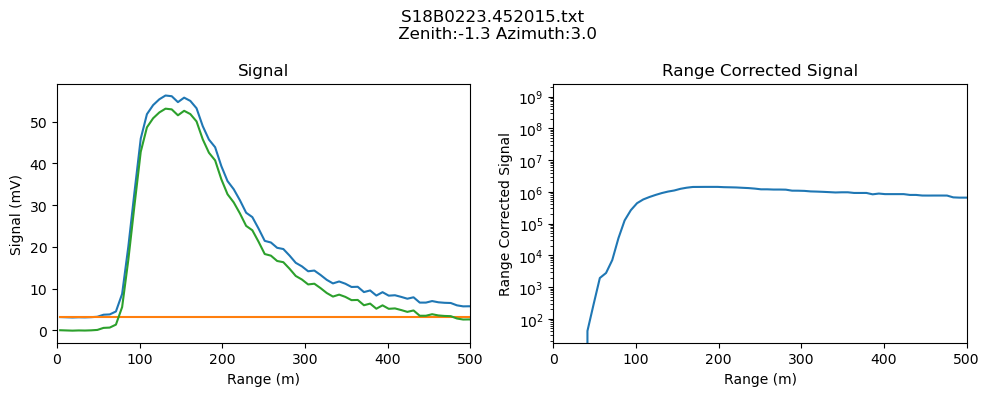

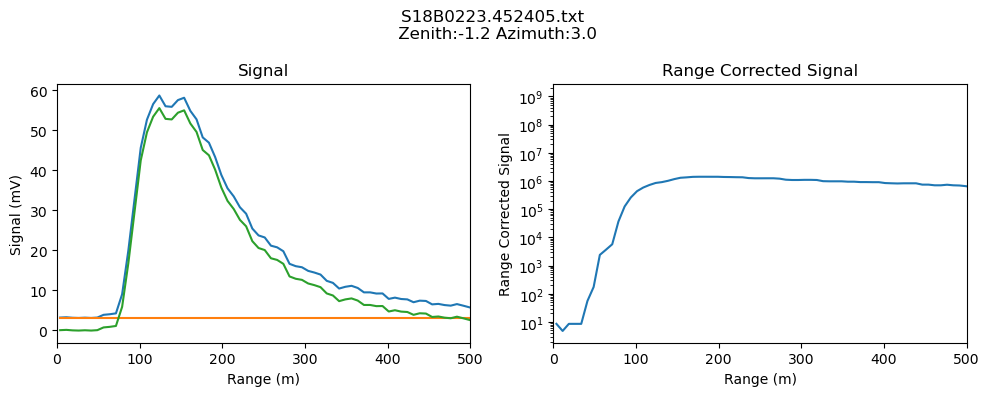

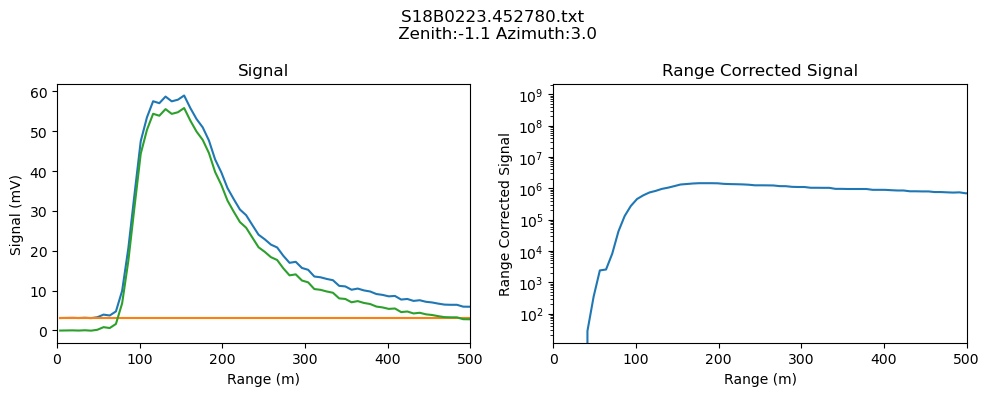

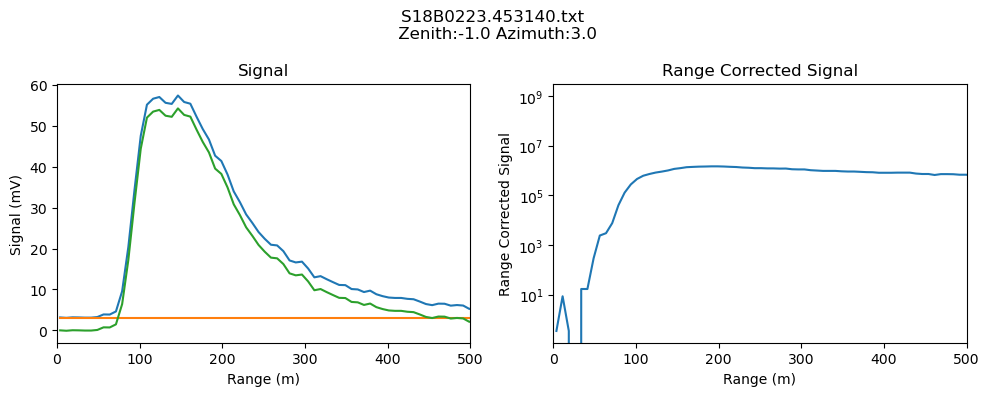

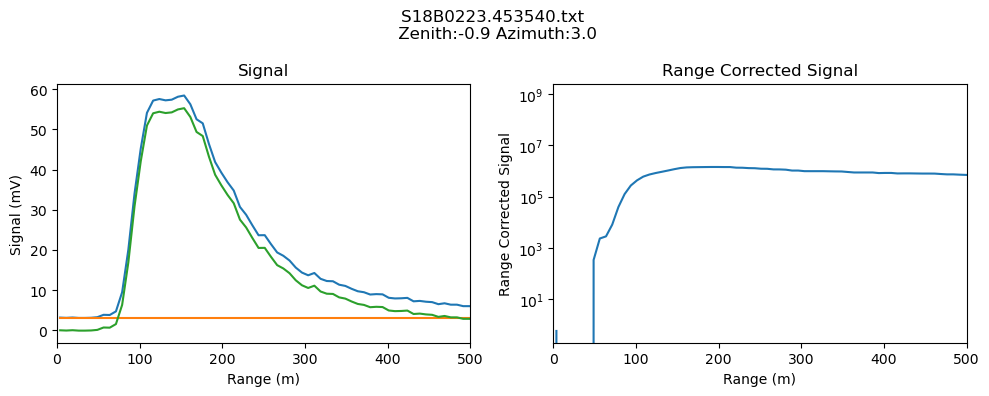

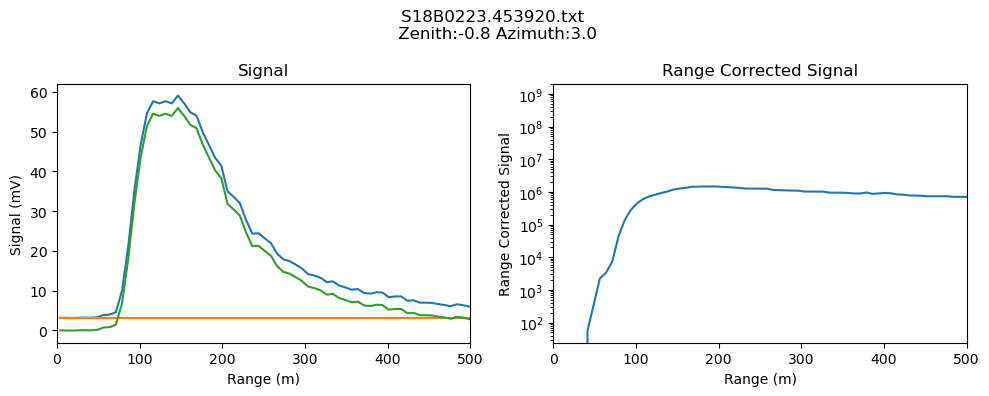

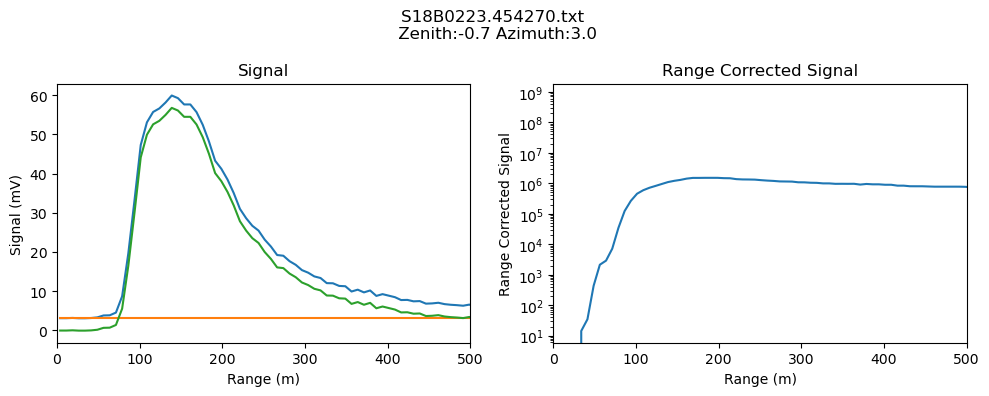

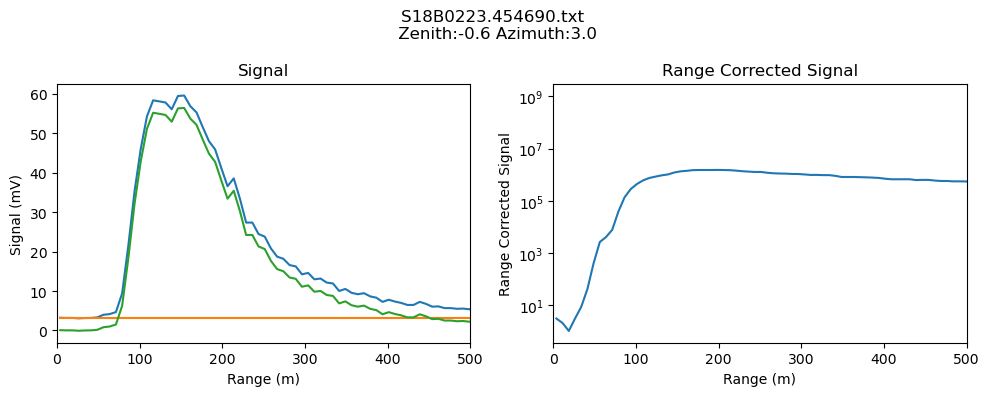

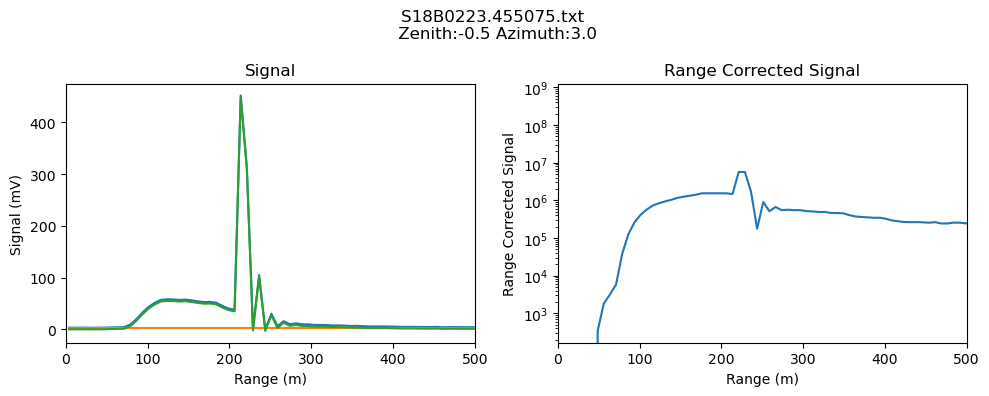

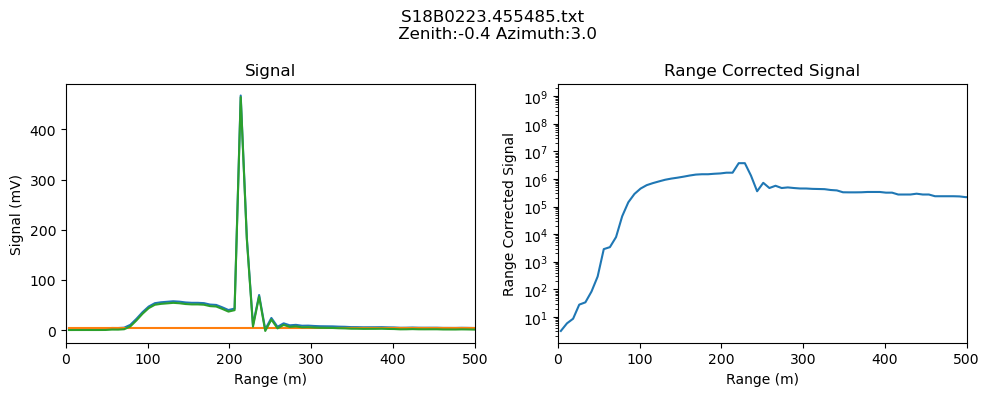

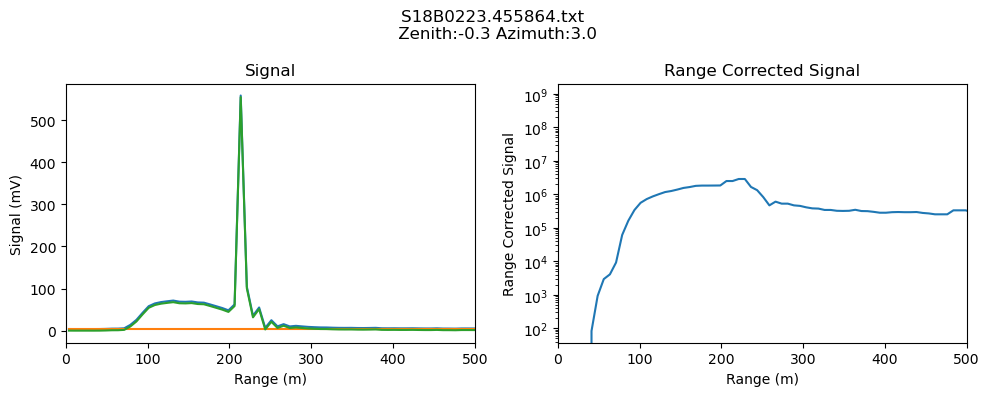

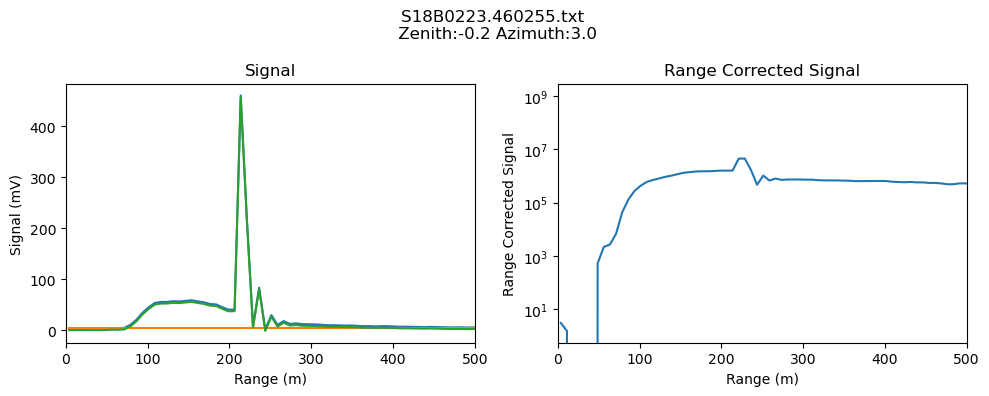

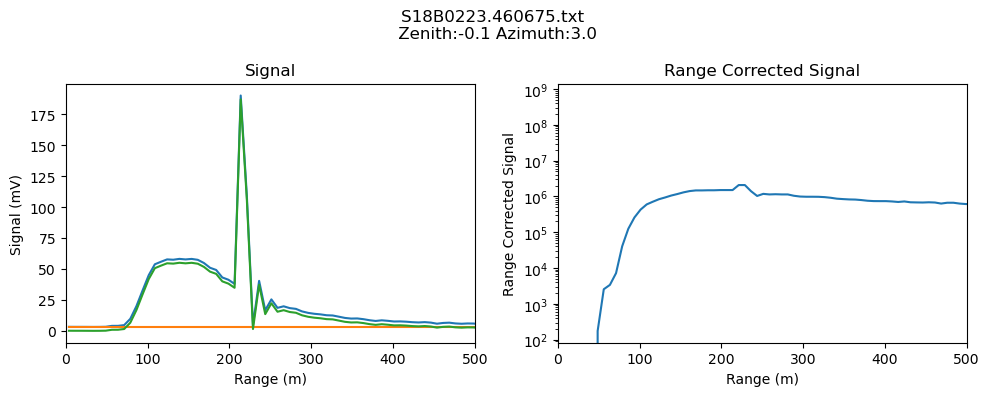

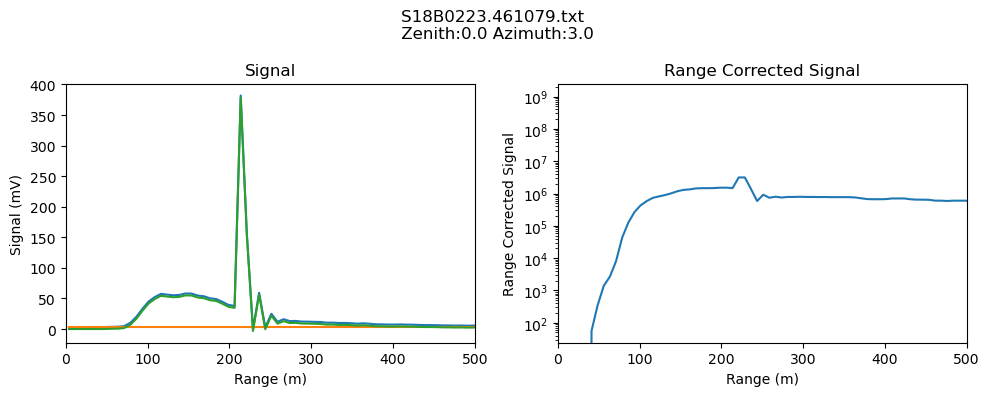

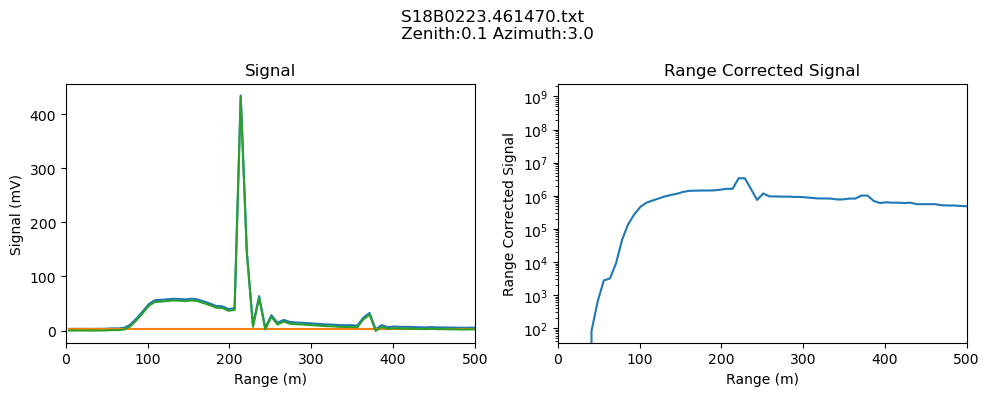

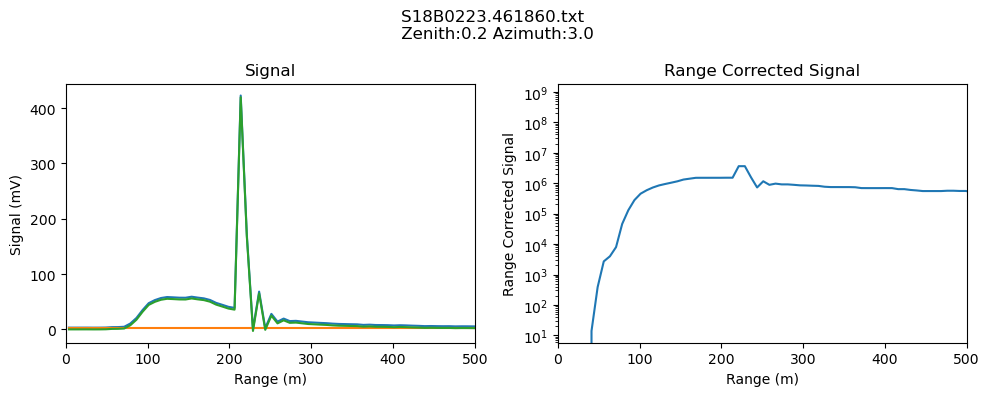

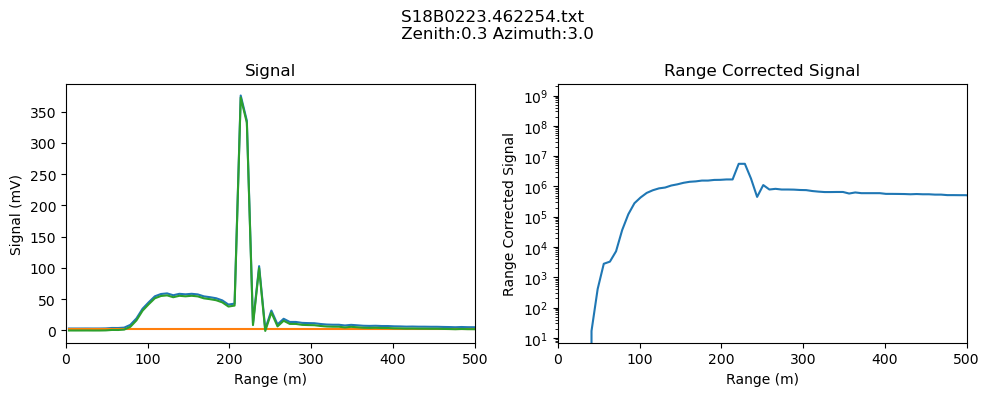

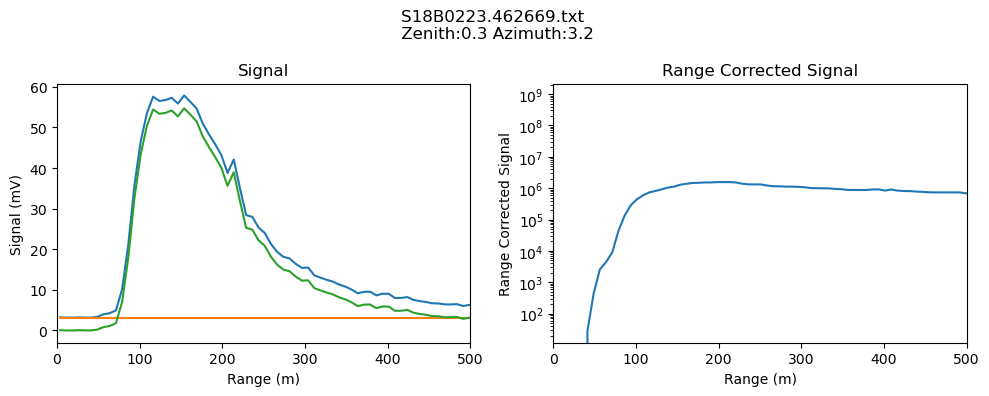

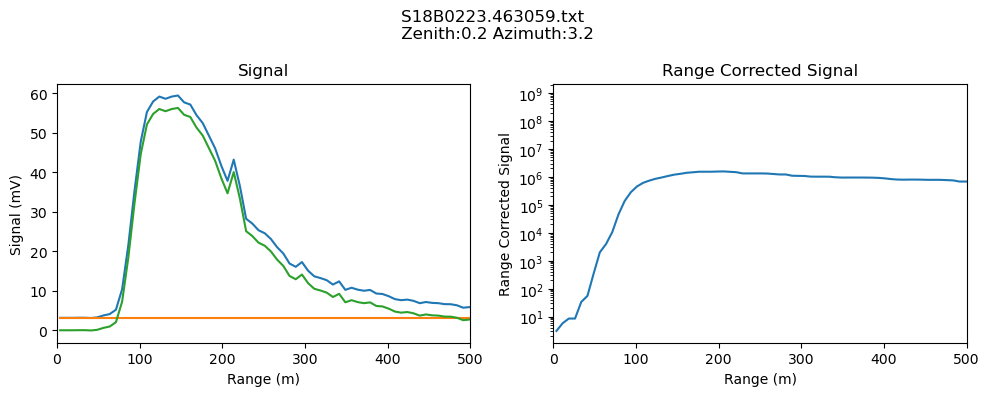

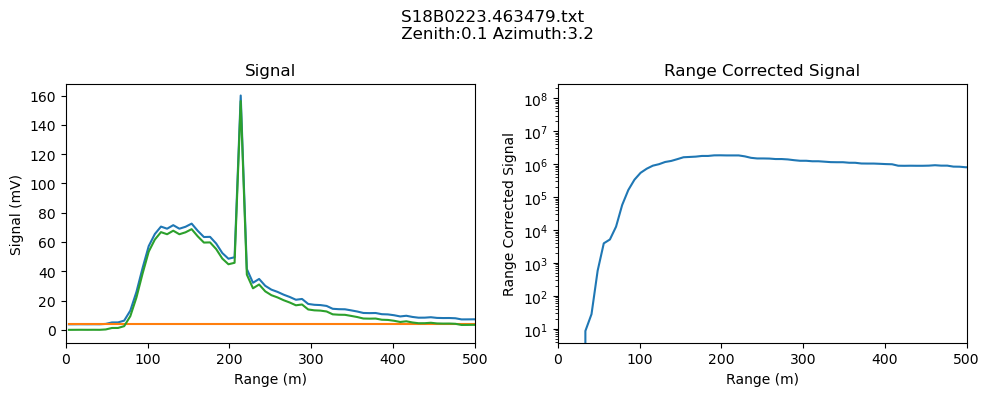

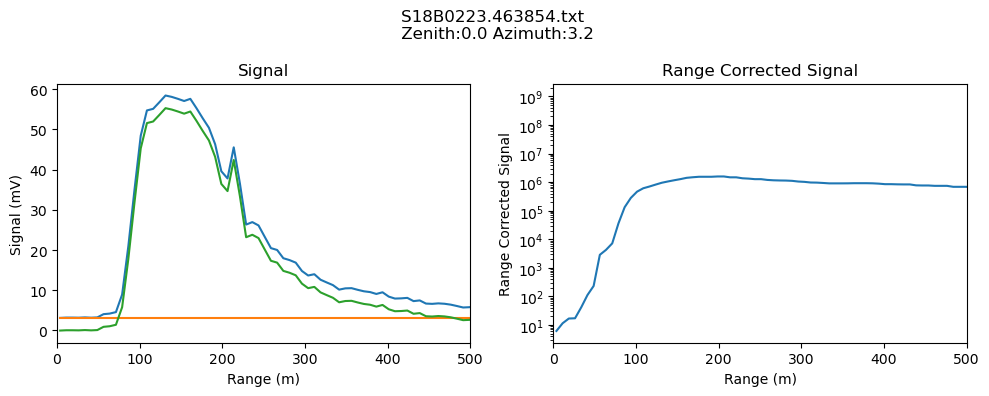

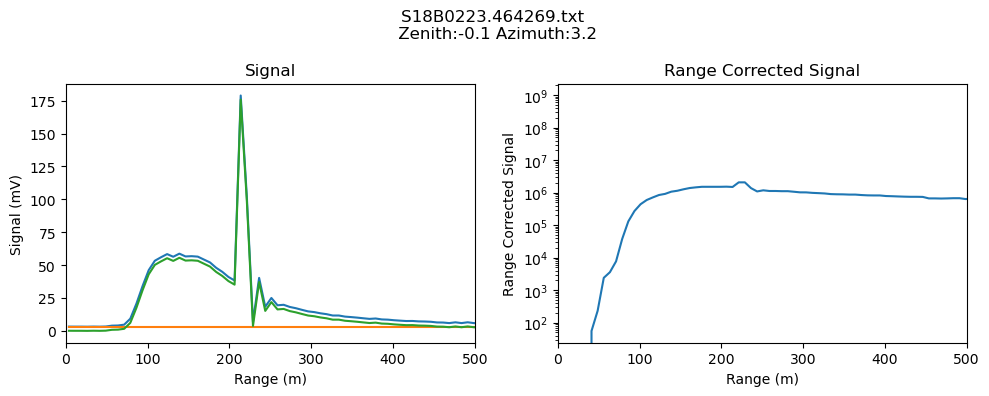

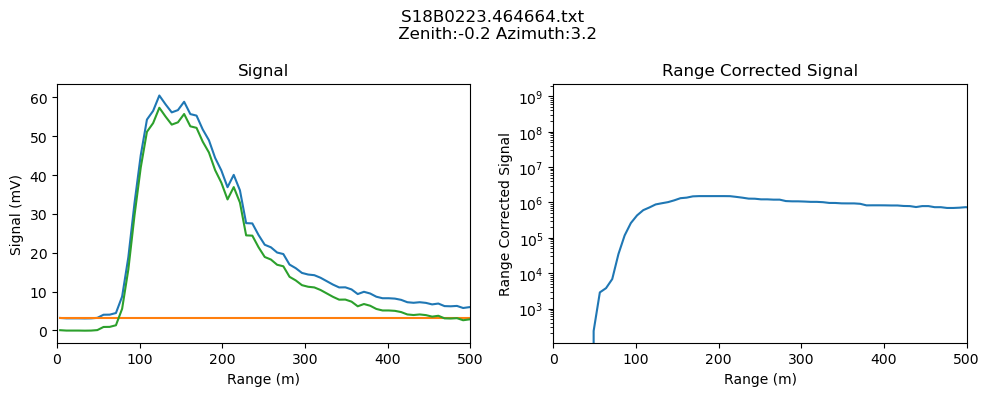

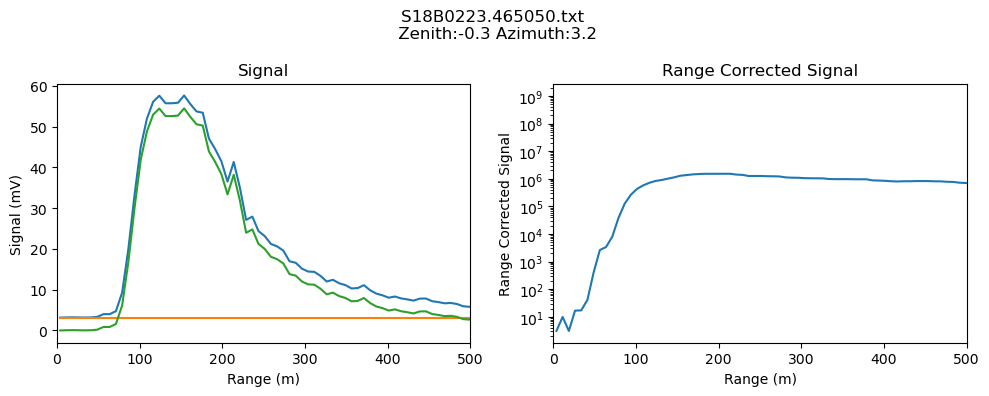

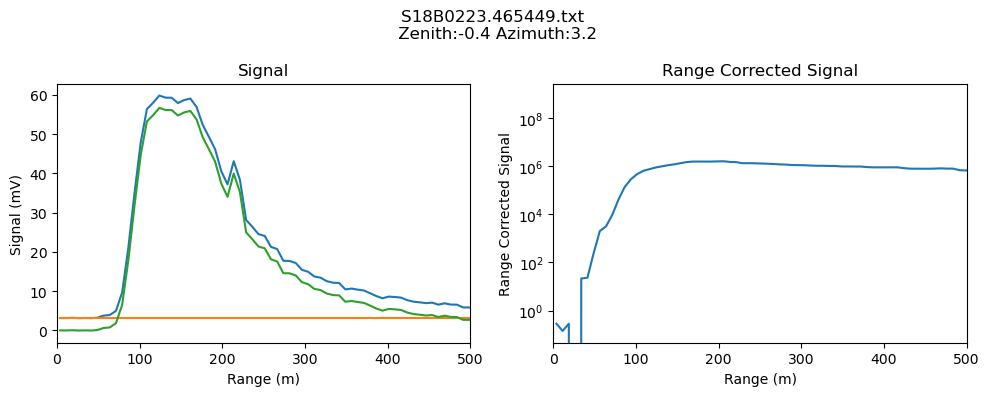

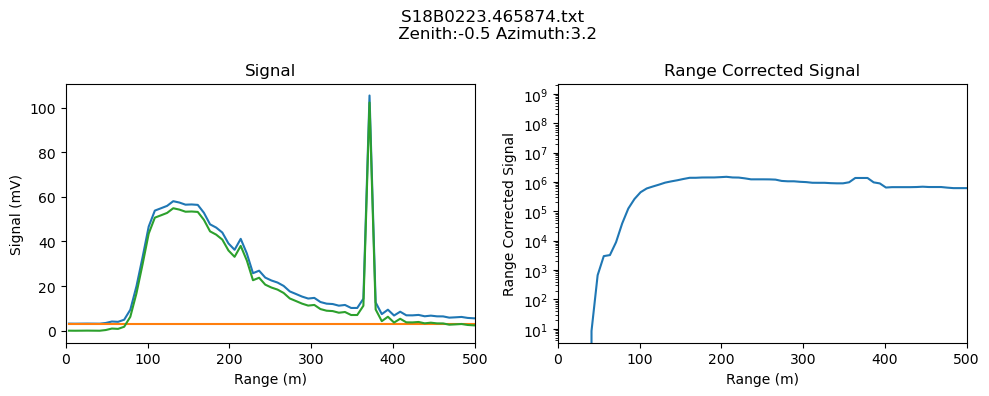

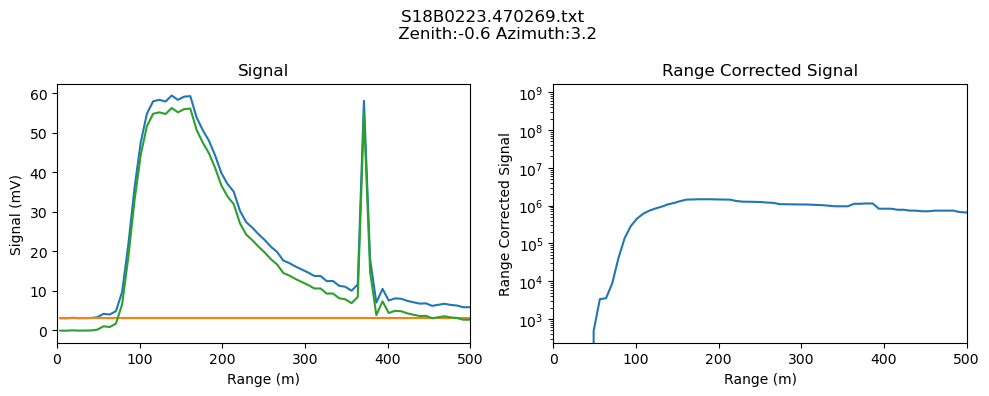

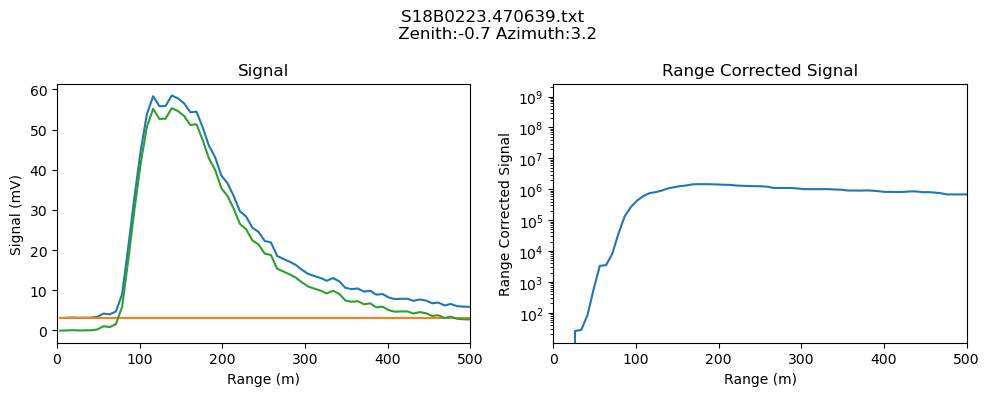

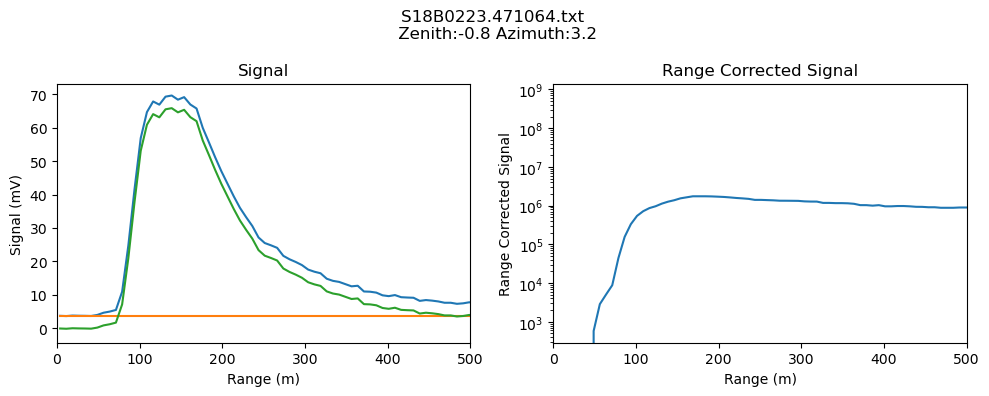

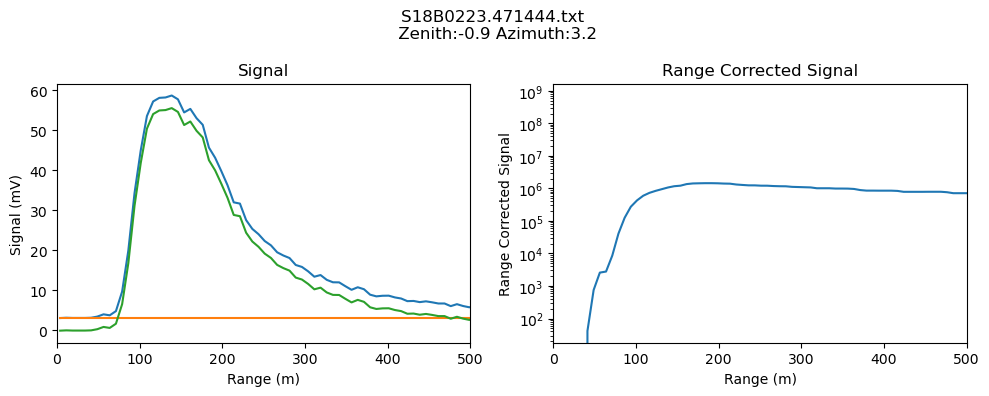

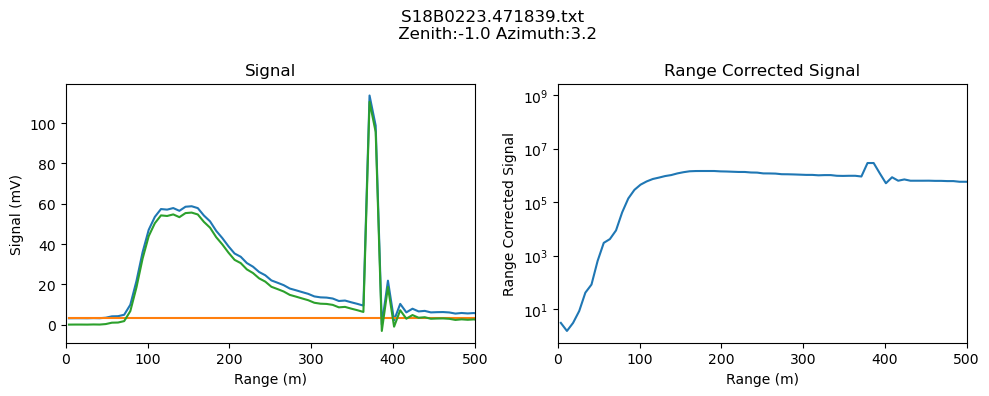

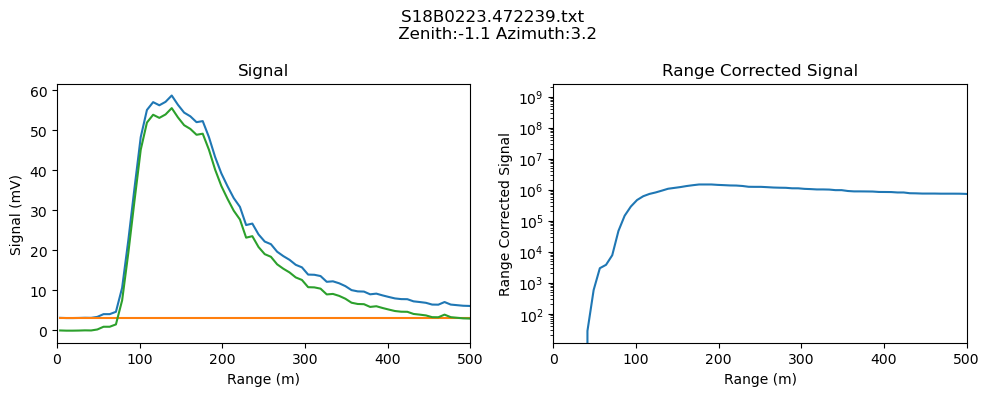

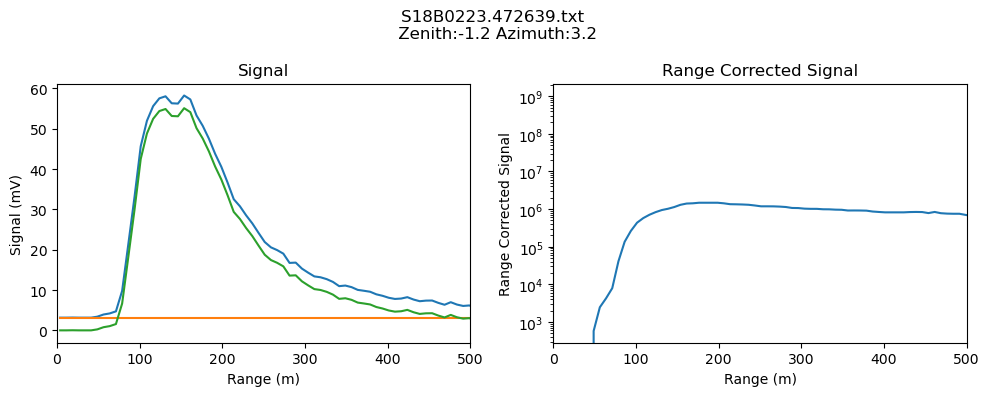

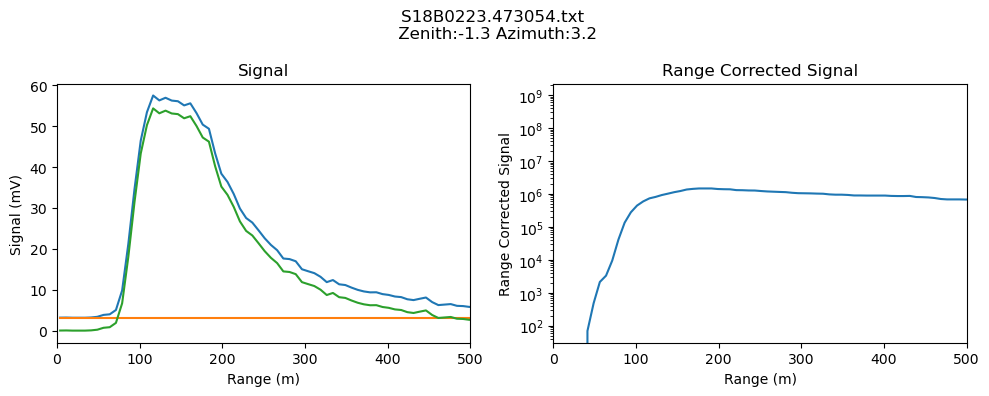

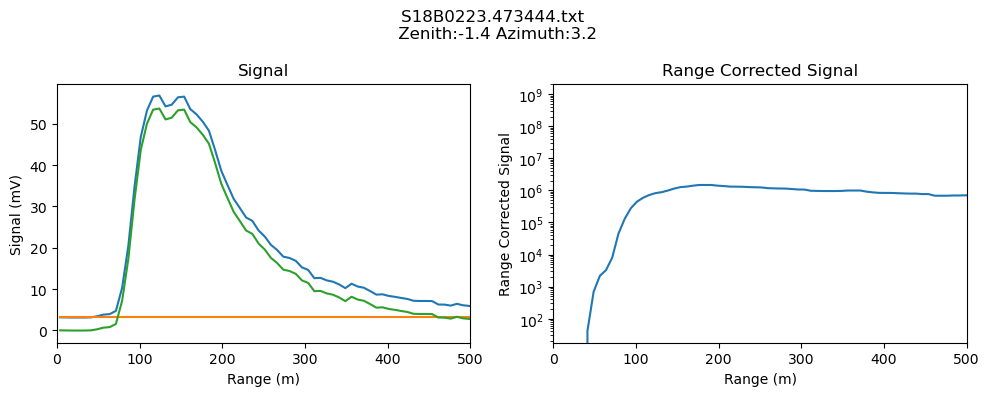

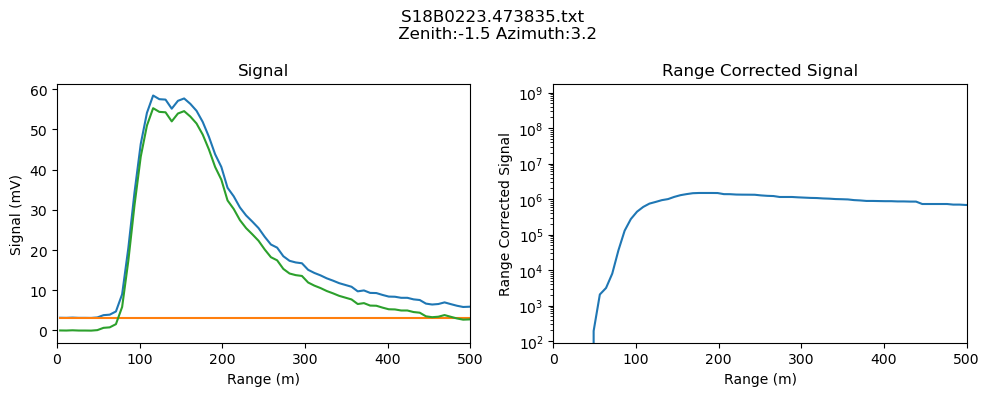

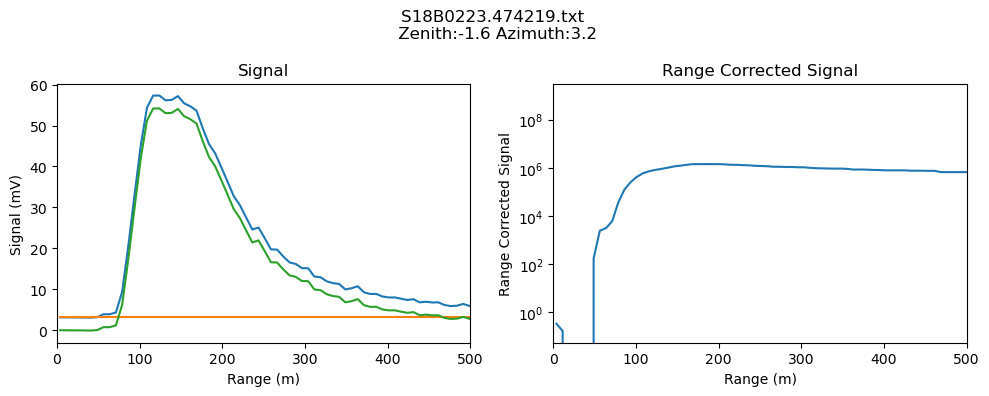

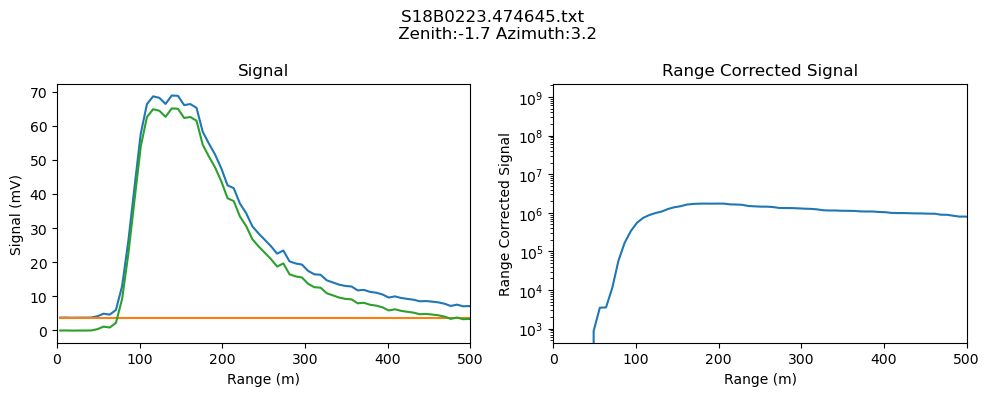

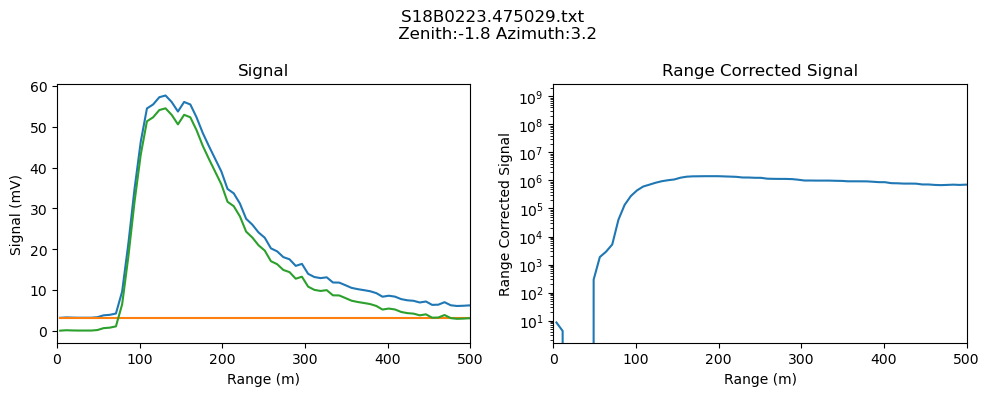

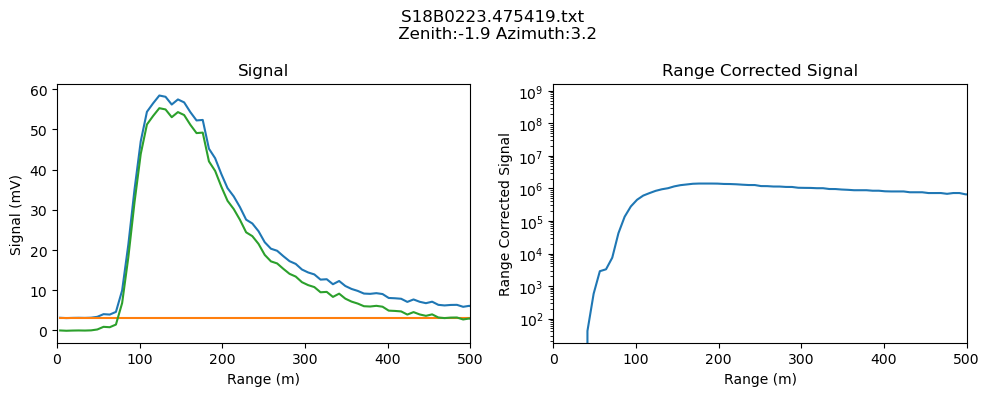

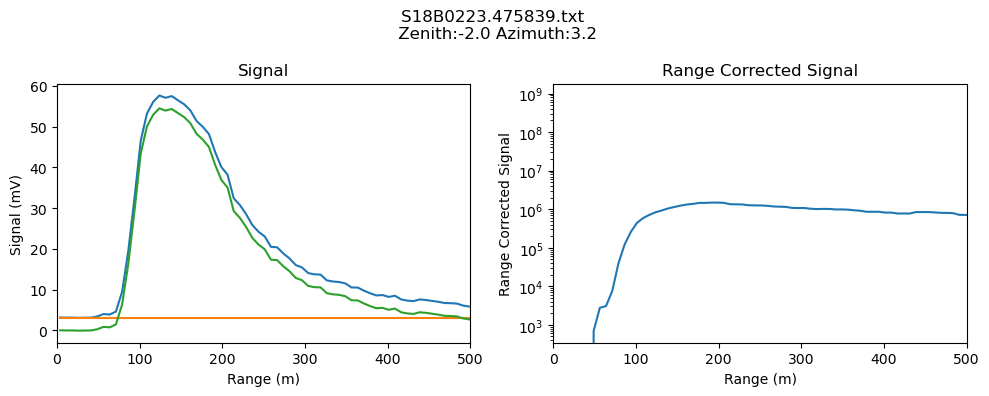

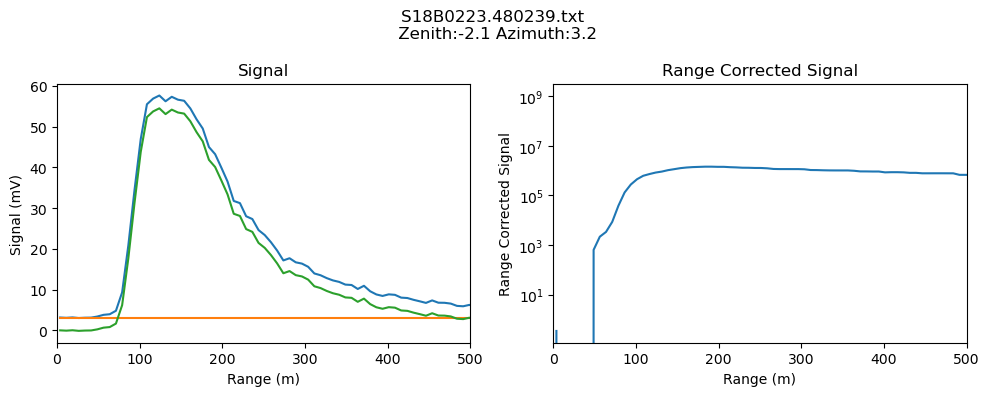

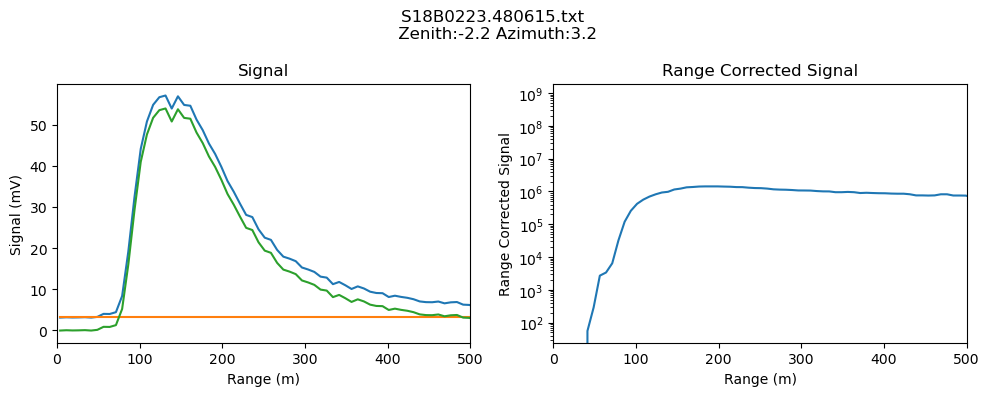

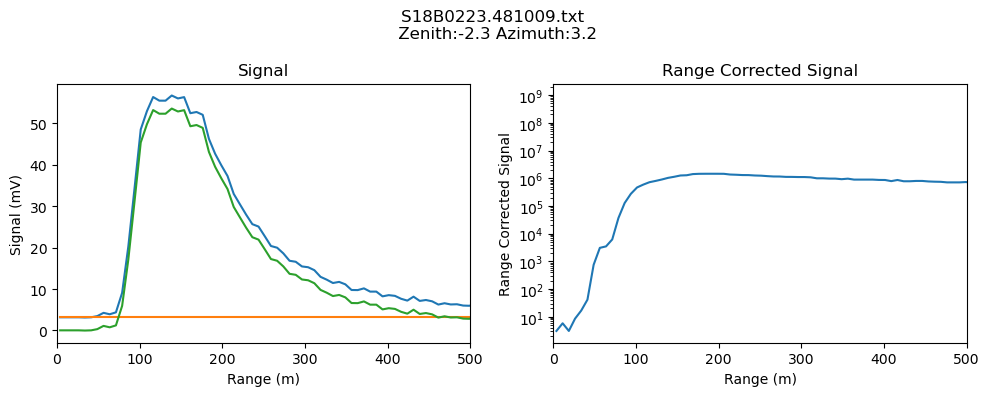

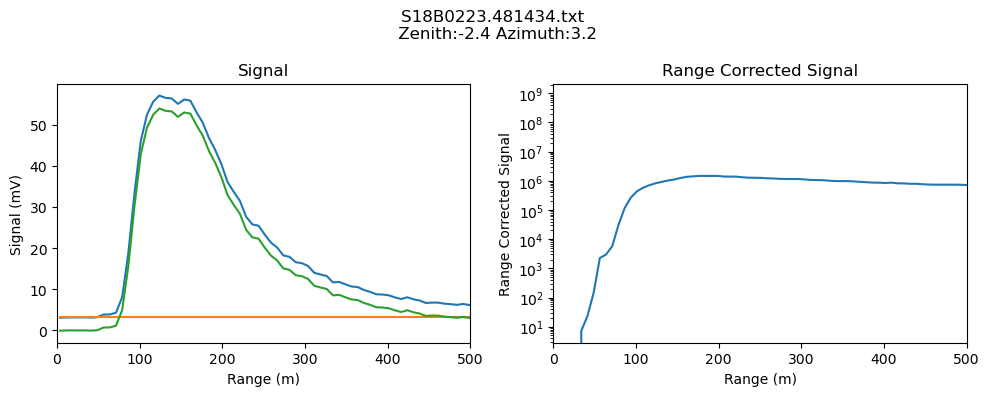

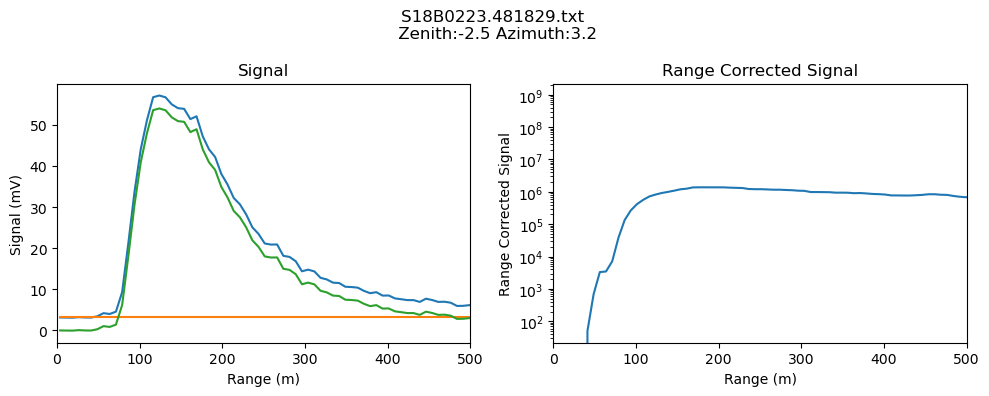

In [ ]:
for file in usc_files:
    usc_meta, usc_profile = read_lidar_file(file, 'USC', 6)
    usc_profile = usc_profile.rename(columns={'355.000 .o analog 0 ': 'analog'})
    df = process_backscatter_profile(usc_profile, 'analog')
    df.loc[df['analog_range_corrected_smoothed'] < 0, 'analog_range_corrected_smoothed'] = 0

    df = df[df['range_m'] < 1000]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # 1. Construct the first subplot to show the raw, background, and corrected signals
    ax1.plot(df['range_m'], df['analog'], label='Raw')
    ax1.plot(df['range_m'], df['analog_background'], label='Background')
    ax1.plot(df['range_m'], df['analog_background_corrected'], label='Corrected')

    ax1.set_title('Signal')
    ax1.set_xlim(0, 500)
    ax1.set_xlabel("Range (m)")
    ax1.set_ylabel("Signal (mV)")

    # 2. Construct the second subplot to show the corrected signal
    ax2.plot(df['range_m'], df['analog_range_corrected_smoothed'], label='Range Corrected')
    ax2.set_ylabel("Range Corrected Signal")
    ax2.set_title('Range Corrected Signal')
    ax2.set_xlabel("Range (m)")
    # ax2.set_ylabel("Signal (mV)")
    ax2.set_xlim(0, 500)
    ax2.set_yscale('log')

    # 3. Fix potential layout overlapping and display
    plt.suptitle(f'{usc_meta.get('file_name')} {'\n'} Zenith:{usc_meta.get('raw_zenith_deg')} Azimuth:{usc_meta.get('raw_azimuth_deg')}')
    plt.tight_layout()
    plt.show()
    
    